# Mixed distributions in QMCPy

## 1. Mixed distributions

Mixtures describe populations or systems with different regimes: normal and
stressed markets, or ordinary and severe insurance claims. If regime $j$ has
probability $p_j$ and distribution $P_j$, then
$$
P_{\mathrm{mix}}=\sum_{j=0}^{s-1}p_jP_j,
\qquad p_j>0,\qquad \sum_j p_j=1.
$$
When the components have densities with respect to a common reference measure,
$$
\rho_{\mathrm{mix}}(x)=\sum_j p_j\rho_j(x).
$$

QMCPy's `Mixture` samples from this target by choosing a component and reusing
its transform. After a short explanation of the selector, we use two
applications to ask why the target mixture matters for an integral, not just
how to generate its samples.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/mixed_distributions.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import quad
from scipy.stats import lognorm, norm
from IPython.display import Markdown, display

from qmcpy import DigitalNetB2, Gaussian, Mixture, SciPyWrapper

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#3366CC", "#E67300", "#2E8B57"]

## 2. Sampling a mixture in QMCPy

For a $d$-dimensional observation, the outer sampler supplies
$u=(u_0,u_1,\ldots,u_d)\in[0,1]^{d+1}$. The selector $u_0$ chooses component $j$
using its cumulative probability interval,
$$
\sum_{k<j}p_k < u_0 \le \sum_{k\le j}p_k,
$$
and only $(u_1,\ldots,u_d)$ enters that component's transform. We assign the
endpoint $u_0=0$ to the first component.

One compact example uses one-dimensional Gaussians centered at $-2$ and $2.5$,
with probabilities $0.3$ and $0.7$. Its outer sampler therefore needs two
coordinates, but the returned observation has only one.

In [3]:
intro_components = [
    Gaussian(DigitalNetB2(1, seed=11), mean=-2.0, covariance=0.35),
    Gaussian(DigitalNetB2(1, seed=13), mean=2.5, covariance=0.55),
]
intro_probabilities = np.array([0.3, 0.7])
intro = Mixture(DigitalNetB2(2, seed=7), intro_components, intro_probabilities)
intro_x = intro(2048)

assert intro_x.shape == (2048, 1)
print("outer sampler dimension:", intro.discrete_distrib.d)
print("output dimension:       ", intro.d)
print("mixture sample shape:   ", intro_x.shape)

outer sampler dimension: 2
output dimension:        1
mixture sample shape:    (2048, 1)


The 2048 two-dimensional uniform inputs become 2048 one-dimensional
observations: $u_0$ chooses the component and $u_1$ supplies its transform.
The selector is consumed, not returned. Component 0 owns $[0,0.3]$ and component 1
owns $(0.3,1]$; the next probe checks the endpoints and the exact shared boundary.

Only this deterministic boundary probe uses the internal `_transform` method;
ordinary sampling in both applications uses the public interface.

In [4]:
boundary_u = np.array([
    [0.0, 0.5],
    [0.3, 0.5],
    [np.nextafter(0.3, 1.0), 0.5],
    [1.0, 0.5],
])
boundary_x = intro._transform(boundary_u)[:, 0]
boundary_component = np.searchsorted(
    np.cumsum(intro_probabilities), boundary_u[:, 0], side="left"
)
boundary_component = np.minimum(boundary_component, 1)

for selector, component, value in zip(
    boundary_u[:, 0], boundary_component, boundary_x
):
    print(f"u0={selector:.17g} -> component {component} -> x={value:.1f}")

np.testing.assert_array_equal(boundary_component, [0, 0, 1, 1])
np.testing.assert_allclose(boundary_x, [-2.0, -2.0, 2.5, 2.5])

u0=0 -> component 0 -> x=-2.0
u0=0.29999999999999999 -> component 0 -> x=-2.0
u0=0.30000000000000004 -> component 1 -> x=2.5
u0=1 -> component 1 -> x=2.5


Both $u_0=0$ and the exact boundary $u_0=0.3$ select component 0 because the
cumulative lookup is left-sided. `np.nextafter(0.3, 1.0)`, the smallest
representable value above that boundary, selects component 1, as does $u_0=1$.
The fixed second coordinate $u_1=0.5$ maps to each Gaussian's median (its mean),
so the four results are $-2,-2,2.5,2.5$: no cumulative boundary is ambiguous.

## 3. Portfolio downside loss: mixture versus non-mixture sampling

Why sample the mixture directly? This main example compares two
sampling strategies for the same expected loss, rather than two
different return models.

### Target and proposal

Let $X$ be portfolio return, expressed as a fraction. This illustrative model
has an 85% normal-market regime with mean $+1\%$ and standard deviation $1.5\%$,
and a 15% stress regime with mean $-8\%$ and standard deviation $3\%$.
These parameters are not a calibrated financial model.

The alternative is a single Gaussian proposal $q=\mathcal{N}(0,0.04^2)$.
It has support on the whole real line but cannot reproduce both regimes.
First, compare its density with the target.

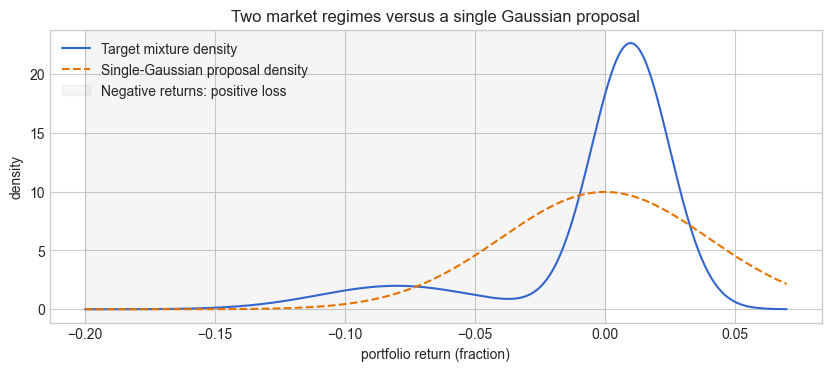

In [5]:
market_probabilities = np.array([0.85, 0.15])
market_means = np.array([0.01, -0.08])
market_sds = np.array([0.015, 0.03])
proposal_mean, proposal_sd = 0.0, 0.04


def market_log_density(y):
    return np.logaddexp(
        np.log(market_probabilities[0])
        + norm.logpdf(y, market_means[0], market_sds[0]),
        np.log(market_probabilities[1])
        + norm.logpdf(y, market_means[1], market_sds[1]),
    )


return_grid = np.linspace(-0.20, 0.07, 900)
fig, ax = plt.subplots(figsize=(8.2, 3.6), layout="constrained")
ax.plot(return_grid, np.exp(market_log_density(return_grid)),
        color=COLORS[0], label="Target mixture density")
ax.plot(return_grid, norm.pdf(return_grid, proposal_mean, proposal_sd),
        color=COLORS[1], linestyle="--", label="Single-Gaussian proposal density")
ax.axvspan(return_grid[0], 0, color="grey", alpha=0.08,
           label="Negative returns: positive loss")
ax.set(xlabel="portfolio return (fraction)", ylabel="density",
       title="Two market regimes versus a single Gaussian proposal")
ax.legend(frameon=False)
plt.show()

The target's tall mode near $0.01$ represents normal markets, while its smaller
mode near $-0.08$ allocates probability to stress returns. The single Gaussian
spreads its mass around zero and does not match both regions equally well.
The shaded negative-return region is where the loss is nonzero; the experiment
below tests the effect of this density mismatch on estimating that loss.

### Reference expected downside loss

We estimate expected downside loss:
$$
g(x)=\max(-x,0), \qquad
I=\mathbb{E}_{\rho_{\mathrm{mix}}}[g(X)]
=\int g(x)\rho_{\mathrm{mix}}(x)\,dx.
$$
Positive returns contribute zero loss; negative returns contribute their loss
magnitude. This is expected downside loss over the full distribution, **not**
the conditional expectation $\mathbb{E}[-X\mid X<0]$.

In [6]:
loss_reference, quadrature_error = quad(
    lambda x: (-x) * np.exp(market_log_density(x)),
    -np.inf, 0.0, epsabs=1e-12, epsrel=1e-12,
)
assert np.isfinite(loss_reference) and quadrature_error < 1e-10
print(f"Reference expected downside loss: {loss_reference:.12f}")
print(f"As a fraction of portfolio value: {100 * loss_reference:.6f}%")
print(f"Quadrature estimated absolute error: {quadrature_error:.2e}")

Reference expected downside loss: 0.013932092872
As a fraction of portfolio value: 1.393209%
Quadrature estimated absolute error: 6.64e-13


Quadrature gives $I_{\mathrm{ref}}\approx0.01393209$, or an unconditional
expected downside loss of about $1.3932\%$ of portfolio value. It integrates
$(-x)\rho_{\mathrm{mix}}(x)$ from $-\infty$ to zero independently of either
sampling method, and is used only as the benchmark for estimator error.

### Convergence comparison

Direct sampling uses `Mixture` and averages $g(X)$ without importance weights.
For the single-Gaussian proposal, correcting the density mismatch gives
$$
I=\mathbb{E}_q\!\left[g(Y)\frac{\rho_{\mathrm{mix}}(Y)}{q(Y)}\right].
$$
We evaluate this density ratio in log space without clipping weights.

Both approaches estimate the same expected downside loss. The comparison
therefore isolates the sampling strategy: direct draws from the target mixture
versus draws from a single Gaussian proposal corrected with importance weights.

Each method uses $R=16$ independent LMS-plus-digital-shift randomizations of
DigitalNetB2, with fixed seeds chosen before the comparison. Within each
replication, nested prefixes give $n=2^6,\ldots,2^{14}$ samples, so the two
methods have equal sample counts; different sizes on a curve are correlated.
Direct sampling needs two uniform coordinates (selector plus transform),
whereas the Gaussian proposal needs one. This compares accuracy per sample,
not equal wall-clock cost.

For each size, we measure
$$
\mathrm{RMSE}(n)=
\sqrt{\frac1R\sum_{r=1}^R(\widehat I_{n,r}-I_{\mathrm{ref}})^2}.
$$

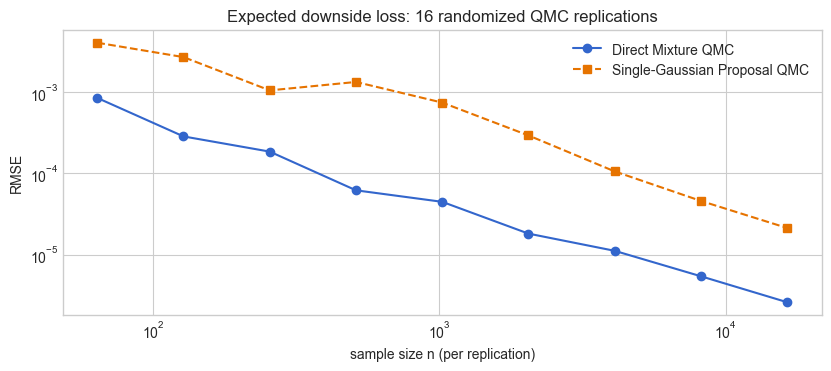

In [7]:
loss_sample_sizes = 2 ** np.arange(6, 15)
loss_replications = 16
market_components = [
    Gaussian(
        DigitalNetB2(1, seed=67 + j),
        mean=market_means[j], covariance=market_sds[j] ** 2,
    )
    for j in range(2)
]
direct_market = Mixture(
    DigitalNetB2(2, seed=71, replications=loss_replications, randomize="LMS DS"),
    market_components, market_probabilities,
)
single_proposal = Gaussian(
    DigitalNetB2(1, seed=73, replications=loss_replications, randomize="LMS DS"),
    mean=proposal_mean, covariance=proposal_sd ** 2,
)

# Public sampling: each row is one independently randomized replication.
market_x = direct_market(int(loss_sample_sizes[-1]))[..., 0]
proposal_y = single_proposal(int(loss_sample_sizes[-1]))[..., 0]
assert market_x.shape == proposal_y.shape == (
    loss_replications, loss_sample_sizes[-1]
)
assert np.all(np.isfinite(market_x)) and np.all(np.isfinite(proposal_y))

proposal_log_pdf = norm.logpdf(proposal_y, proposal_mean, proposal_sd)
assert np.all(np.isfinite(proposal_log_pdf))
importance_weights = np.exp(
    market_log_density(proposal_y) - proposal_log_pdf
)
assert np.all(np.isfinite(importance_weights)) and np.all(importance_weights > 0)

direct_loss = np.maximum(-market_x, 0.0)
weighted_loss = np.maximum(-proposal_y, 0.0) * importance_weights
assert np.all(np.isfinite(weighted_loss))
direct_estimates = np.array([
    direct_loss[:, :n].mean(axis=1) for n in loss_sample_sizes
])
proposal_estimates = np.array([
    weighted_loss[:, :n].mean(axis=1) for n in loss_sample_sizes
])
direct_rmse = np.sqrt(np.mean((direct_estimates - loss_reference) ** 2, axis=1))
proposal_rmse = np.sqrt(np.mean((proposal_estimates - loss_reference) ** 2, axis=1))

assert direct_estimates.shape == proposal_estimates.shape == (
    len(loss_sample_sizes), loss_replications
)
assert direct_rmse.shape == proposal_rmse.shape == loss_sample_sizes.shape
assert np.all(np.isfinite(direct_rmse)) and np.all(direct_rmse >= 0)
assert np.all(np.isfinite(proposal_rmse)) and np.all(proposal_rmse >= 0)

fig, ax = plt.subplots(figsize=(8.2, 3.6), layout="constrained")
ax.loglog(loss_sample_sizes, direct_rmse, "o-", color=COLORS[0],
          label="Direct Mixture QMC")
ax.loglog(loss_sample_sizes, proposal_rmse, "s--", color=COLORS[1],
          label="Single-Gaussian Proposal QMC")
ax.set(xlabel="sample size n (per replication)", ylabel="RMSE",
       title="Expected downside loss: 16 randomized QMC replications")
ax.legend(frameon=False)
plt.show()

Direct mixture sampling has lower empirical RMSE at every tested sample size
in this experiment. Both curves estimate the same expected downside loss,
but direct samples follow the target regime probabilities, whereas proposal
samples compensate for the density mismatch with variable importance weights.
Those weights can increase estimator variability, particularly for stress
returns that the proposal undersamples. The curves quantify an empirical
accuracy difference, not an asserted asymptotic convergence order; with only
16 replications, the measured RMSE itself has sampling variability.

In [8]:
representative_sizes = [256, 1024, 4096, 16384]
table_lines = [
    "| n | Direct Mixture RMSE | Single Proposal RMSE | Proposal / Mixture |",
    "| ---: | ---: | ---: | ---: |",
]
for n in representative_sizes:
    i = int(np.flatnonzero(loss_sample_sizes == n)[0])
    table_lines.append(
        f"| {n} | {direct_rmse[i]:.6e} | {proposal_rmse[i]:.6e} | "
        f"{proposal_rmse[i] / direct_rmse[i]:.2f} |"
    )
display(Markdown("\n".join(table_lines)))

| n | Direct Mixture RMSE | Single Proposal RMSE | Proposal / Mixture |
| ---: | ---: | ---: | ---: |
| 256 | 1.859824e-04 | 1.057574e-03 | 5.69 |
| 1024 | 4.471536e-05 | 7.475718e-04 | 16.72 |
| 4096 | 1.113080e-05 | 1.060660e-04 | 9.53 |
| 16384 | 2.587320e-06 | 2.127985e-05 | 8.22 |

The last column divides the single-Gaussian proposal RMSE by the direct-mixture
RMSE for the same expected downside loss. The proposal's RMSE is **16.72 times**
as large at $n=1024$ and **8.22 times** as large at $n=16384$, quantifying its
lower accuracy per sample in this experiment. This is not a claim that mixture sampling always wins: a proposal
tailored to the loss integrand, or another integration problem, can behave
differently.

## 4. Insurance stop-loss

### Claim model and retention

Let $X>0$ be claim severity, measured in **thousands of currency units**.
Use a 95% ordinary-claim regime with median 2 (2,000 units) and log-scale
standard deviation 0.5, and a 5% severe-claim regime with median 20 (20,000 units)
and log-scale standard deviation 0.8. The severe regime is both larger and more
dispersed. These are illustrative parameters, not calibrated insurance data.

Both components are lognormal. In SciPy, `scale` is the median and `s` is the
standard deviation of the natural logarithm, not the standard deviation of $X$.
`SciPyWrapper` reuses these distributions' inverse CDFs inside `Mixture`.

Choose retention $d=10$ (10,000 units): five times the ordinary median and half
the severe median. We estimate
$$
g(x)=(x-d)_+=\max(x-d,0),\qquad
I=\mathbb{E}_{\rho_{\mathrm{mix}}}[(X-d)_+].
$$
Claims below the retention contribute zero; larger claims contribute only the
excess above it. Thus $I$ is the expected payment above retention **per claim
across the whole population**, not a conditional average among large claims.
Here $d$ denotes the retention threshold, not the sampler dimension.

A model of ordinary claims alone may describe the body but omit the rarer
severe regime. That omission matters disproportionately for a payoff that
grows with large claims above the threshold.

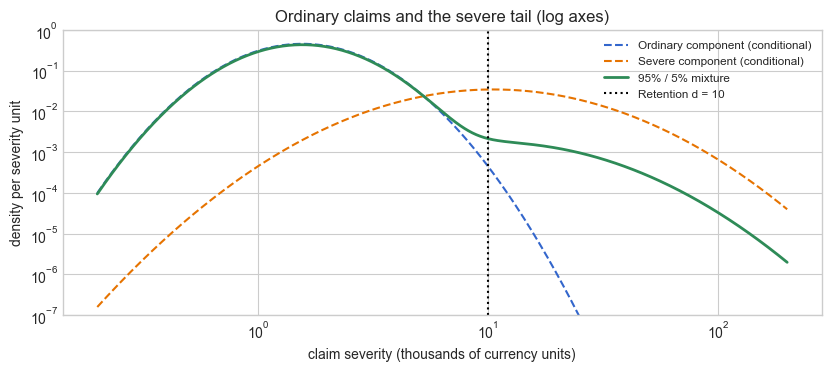

In [9]:
claim_probabilities = np.array([0.95, 0.05])
claim_distributions = [
    lognorm(s=0.5, scale=2.0),
    lognorm(s=0.8, scale=20.0),
]
retention = 10.0


def claim_mixture_pdf(x):
    return sum(
        probability * distribution.pdf(x)
        for probability, distribution in zip(
            claim_probabilities, claim_distributions
        )
    )


claim_grid = np.geomspace(0.2, 200.0, 700)
fig, ax = plt.subplots(figsize=(8.2, 3.6), layout="constrained")
ax.loglog(claim_grid, claim_distributions[0].pdf(claim_grid),
          "--", color=COLORS[0], label="Ordinary component (conditional)")
ax.loglog(claim_grid, claim_distributions[1].pdf(claim_grid),
          "--", color=COLORS[1], label="Severe component (conditional)")
ax.loglog(claim_grid, claim_mixture_pdf(claim_grid),
          color=COLORS[2], linewidth=2, label="95% / 5% mixture")
ax.axvline(retention, color="black", linestyle=":", label="Retention d = 10")
ax.set(xlabel="claim severity (thousands of currency units)",
       ylabel="density per severity unit", ylim=(1e-7, 1.0),
       title="Ordinary claims and the severe tail (log axes)")
ax.legend(loc="upper right", framealpha=1.0, fontsize=8.5)
plt.show()

The mixture largely follows the ordinary-claim body but retains a severe tail
to the right of the retention line. Dashed curves are the conditional component
densities; the solid curve weights them by 0.95 and 0.05.
Logarithmic axes make both scales visible, the plotted values remain densities
of $X$, not of $\log X$. The plotting window is finite, but the reference below
integrates the entire tail to infinity.

### Expected stop-loss payment

Use direct `Mixture` sampling with 16 independent randomized digital nets and
16,384 samples per replication. Average the stop-loss payoffs within each
replication, then average those estimates; no importance weights are needed.

Independently, quadrature computes
$$
I_{\mathrm{ref}}=\int_d^\infty (x-d)\rho_{\mathrm{mix}}(x)\,dx.
$$
We also decompose this same reference into ordinary and severe contributions,
$p_j\int_d^\infty(x-d)\rho_j(x)\,dx$. This isolates the effect of the rare
regime without repeating the portfolio's proposal-comparison experiment.

In [10]:
claim_components = [
    SciPyWrapper(DigitalNetB2(1, seed=81 + j), distribution)
    for j, distribution in enumerate(claim_distributions)
]
claim_mixture = Mixture(
    DigitalNetB2(2, seed=83, replications=16, randomize="LMS DS"),
    claim_components, claim_probabilities,
)
claim_samples = claim_mixture(2**14)[..., 0]
assert claim_samples.shape == (16, 2**14)
assert np.all(np.isfinite(claim_samples)) and np.all(claim_samples > 0)
stop_loss_by_replication = np.maximum(
    claim_samples - retention, 0.0
).mean(axis=1)
stop_loss_estimate = stop_loss_by_replication.mean()

stop_loss_reference, stop_loss_quad_error = quad(
    lambda x: (x - retention) * claim_mixture_pdf(x),
    retention, np.inf, epsabs=1e-10, epsrel=1e-10,
)
stop_loss_rmse = np.sqrt(
    np.mean((stop_loss_by_replication - stop_loss_reference) ** 2)
)
component_stop_loss = np.array([
    quad(
        lambda x: (x - retention) * distribution.pdf(x),
        retention, np.inf, epsabs=1e-10, epsrel=1e-10,
    )[0]
    for distribution in claim_distributions
])
weighted_contributions = claim_probabilities * component_stop_loss
severe_share = weighted_contributions[1] / stop_loss_reference
np.testing.assert_allclose(
    weighted_contributions.sum(), stop_loss_reference, rtol=1e-10, atol=1e-10
)
assert stop_loss_quad_error < 1e-8

# Convert from thousands to currency units only for reporting.
print(f"Direct Mixture QMC estimate: {1000 * stop_loss_estimate:.2f}")
print(f"Quadrature reference:        {1000 * stop_loss_reference:.2f}")
print(f"Absolute error:              {1000 * abs(stop_loss_estimate - stop_loss_reference):.2f}")
print(f"Replication RMSE:           {1000 * stop_loss_rmse:.2f}")
print(f"Ordinary contribution:       {1000 * weighted_contributions[0]:.2f}")
print(f"Severe contribution:         {1000 * weighted_contributions[1]:.2f}")
print(f"Severe share of reference:   {100 * severe_share:.2f}%")
print("All amounts are currency units per claim.")

Direct Mixture QMC estimate: 910.42
Quadrature reference:        908.78
Absolute error:              1.64
Replication RMSE:           9.33
Ordinary contribution:       0.94
Severe contribution:         907.85
Severe share of reference:   99.90%
All amounts are currency units per claim.


The direct estimate is **910.42** currency units per claim, versus the
independent reference of **908.78**, an absolute difference of **1.64**.
This is the average payment of only the excess above 10,000, including zero
payments for claims below retention; it is not conditional on a claim exceeding
retention.

The empirical RMSE across the 16 individual replication estimates is **9.33**
currency units per claim. It measures error at 16,384 samples per replication,
not the error of their average: the latter is the displayed **1.64** absolute
difference from quadrature.

The reference assigns about **0.94** to the ordinary regime and **907.85** to the
severe regime. The displayed severe share, **99.90%**, is the fraction of the
reference payment attributable to the 5% severe-claim population. A body-only
model would miss nearly all of this expectation. These are contributions to the same mixture integral, not a
comparison of numerical estimators with different targets; the reported QMC
error is an observed error, not a guaranteed error bound.

## 5. Scope and limitations

- Components must share an output dimension; the outer sampler needs exactly
  one additional selector coordinate. Probabilities must be finite, positive,
  and sum to one.
- A density formula requires component densities with respect to a common
  reference measure. Components with point masses need a measure-level
  interpretation, not a smooth density curve.
- Direct mixture sampling is not always the most accurate strategy. The payoff,
  proposal, rare-event probabilities, and tail behavior all matter; equal sample
  counts also need not mean equal computational cost.
- These application parameters are illustrative. Neither numerical precision
  nor a good QMC result establishes that a model fits real data.

## 6. Summary

`Mixture` represents targets composed of distinct regimes or populations and
samples them using existing component transforms.

The portfolio example shows that direct mixture sampling can outperform a
mismatched single-Gaussian importance-sampling proposal for the same integral.
For the illustrative insurance model, a small severe-claim component dominates
a tail-sensitive quantity: expected stop-loss payment.

These outcomes depend on the target, payoff, and sampling strategy; mixture
sampling is not universally superior.